In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\Users\Downloads\xAPI-Edu-Data.csv")
print(df.shape)
df.head()

(480, 17)


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [2]:
# Check for issues before cleaning
print(df.isnull().sum())
print(df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Fix column names
df = df.rename(columns={
    "NationalITy": "Nationality",
    "PlaceofBirth": "PlaceOfBirth",
    "VisITedResources": "VisitedResources"
})

# Fix inconsistent country names
fix_map = {
    "KW": "Kuwait",
    "KuwaIT": "Kuwait",
    "Tunis": "Tunisia",
    "Lybia": "Libya",
    "venzuela": "Venezuela",
    "lebanon": "Lebanon"
}
df["Nationality"] = df["Nationality"].str.strip().replace(fix_map)
df["PlaceOfBirth"] = df["PlaceOfBirth"].str.strip().replace(fix_map)

# Fix StageID casing
df["StageID"] = df["StageID"].replace({"lowerlevel": "LowerLevel"})

# Extract numeric grade
df["GradeNumber"] = df["GradeID"].str.extract(r"G-(\d+)").astype(int)

# Readability tweaks
df["gender"] = df["gender"].map({"M": "Male", "F": "Female"})
df["Relation"] = df["Relation"].replace({"Mum": "Mother"})

# Verify cleaning worked
print(df.nunique())
df.head()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64
2
gender                       2
Nationality                 14
PlaceOfBirth                14
StageID                      3
GradeID                     10
SectionID                    3
Topic                       12
Semester                     2
Relation                     2
raisedhands                 82
VisitedResources            89
AnnouncementsView           88
Discussion                  90
ParentAnsweringSurvey        2
ParentschoolSatisfaction     2
StudentAbs

,gender,Nationality,PlaceOfBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisitedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,GradeNumber
0,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,4
1,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,4
2,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,4
3,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,4
4,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,4


In [3]:
# Create a copy specifically for correlation/modeling — keep the readable df separate
df_encoded = df.copy()

# Binary categoricals → 0/1
df_encoded["gender"] = df_encoded["gender"].map({"Male": 0, "Female": 1})
df_encoded["Semester"] = df_encoded["Semester"].map({"F": 0, "S": 1})
df_encoded["Relation"] = df_encoded["Relation"].map({"Father": 0, "Mother": 1})
df_encoded["ParentAnsweringSurvey"] = df_encoded["ParentAnsweringSurvey"].map({"Yes": 1, "No": 0})
df_encoded["ParentschoolSatisfaction"] = df_encoded["ParentschoolSatisfaction"].map({"Good": 1, "Bad": 0})
df_encoded["StudentAbsenceDays"] = df_encoded["StudentAbsenceDays"].map({"Under-7": 0, "Above-7": 1})

# Ordinal target — order matters here, so map not dummies
df_encoded["Class"] = df_encoded["Class"].map({"L": 0, "M": 1, "H": 2})

# High-cardinality categoricals (many unique values, no natural order) → one-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=["Nationality", "PlaceOfBirth", "StageID", "Topic", "SectionID"], drop_first=True)

print(df_encoded.shape)
df_encoded.dtypes

(478, 54)


gender                       int64
GradeID                     object
Semester                     int64
Relation                     int64
raisedhands                  int64
VisitedResources             int64
AnnouncementsView            int64
Discussion                   int64
ParentAnsweringSurvey        int64
ParentschoolSatisfaction     int64
StudentAbsenceDays           int64
Class                        int64
GradeNumber                  int64
Nationality_Iran              bool
Nationality_Iraq              bool
Nationality_Jordan            bool
Nationality_Kuwait            bool
Nationality_Lebanon           bool
Nationality_Libya             bool
Nationality_Morocco           bool
Nationality_Palestine         bool
Nationality_SaudiArabia       bool
Nationality_Syria             bool
Nationality_Tunisia           bool
Nationality_USA               bool
Nationality_Venezuela         bool
PlaceOfBirth_Iran             bool
PlaceOfBirth_Iraq             bool
PlaceOfBirth_Jordan 

In [4]:
df_encoded = df_encoded.drop(columns=["GradeID"])

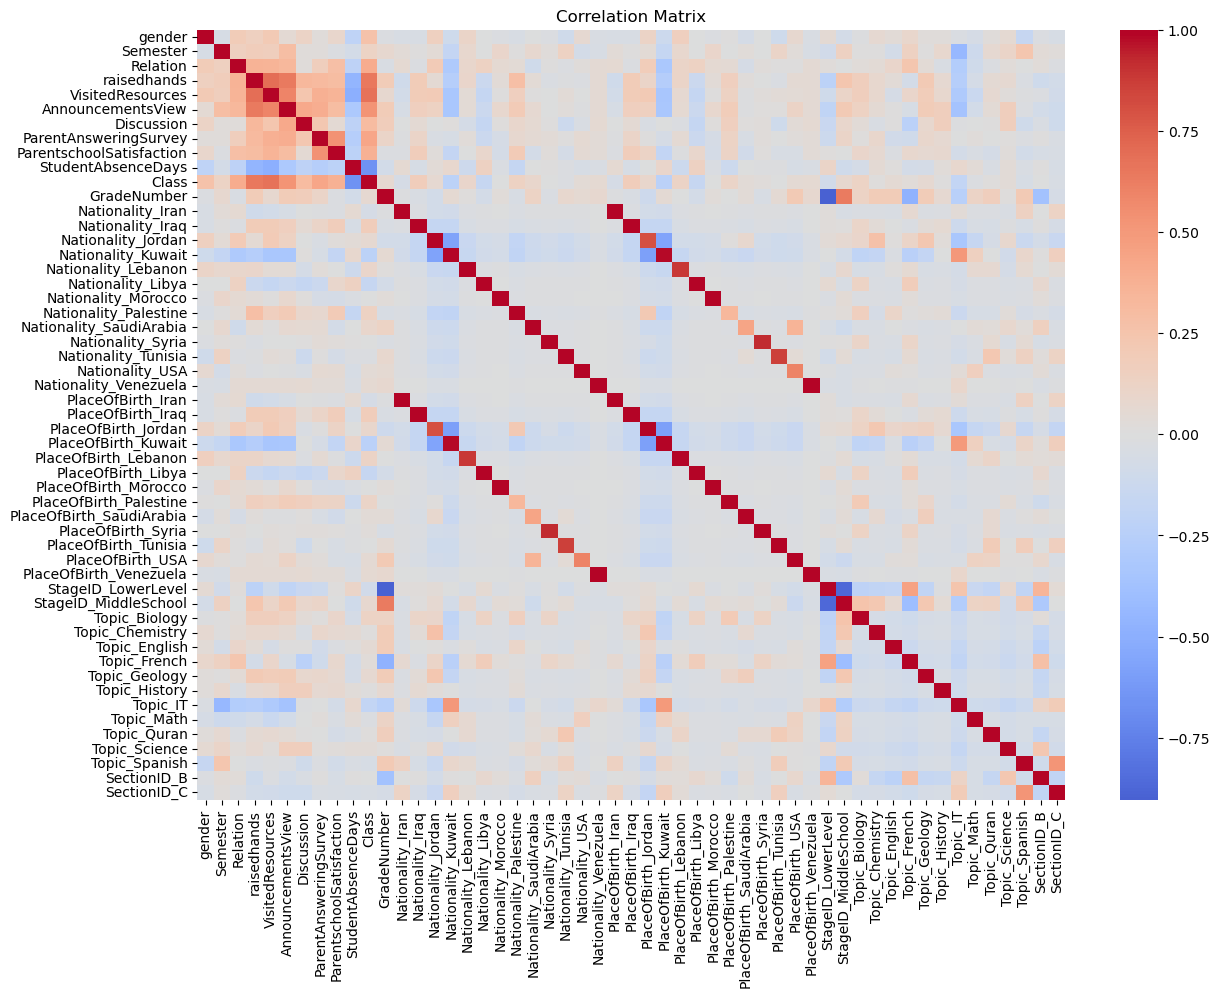

In [5]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [6]:
# Add the ordinal target column to your readable, cleaned dataset
df["Class_encoded"] = df["Class"].map({"L": 0, "M": 1, "H": 2})

# Save the readable version — categorical labels intact + one numeric target column
df.to_csv(r"D:\Users\Downloads\cleaned_student_data.csv", index=False)

# Save the fully-encoded version — everything numeric, ready for correlation/modeling
df_encoded.to_csv(r"D:\Users\Downloads\encoded_student_data.csv", index=False)

print("Both files saved successfully.")

Both files saved successfully.


In [7]:
import os
print(os.listdir(r"D:\Users\Downloads"))

['.ipynb_checkpoints', '11.+EDA.pdf', '12.+13.+14.+Methods+of+EDA.pdf', '16.+DTP.pdf', '17.+18.+Mthods+of+DTP.pdf', '18. IP Addressing- IP classes.mp4', '20.+Joining.pdf', '21.+Concatenating.pdf', '2nd Presentation Dr Gamaldeen Meat Quality.pdf', '2ND Watermark.png', '4cebe96e-3916-49c6-90bb-fd64757c55b7.png', '5.+Data+source.pdf', '6.+Sampling+methods.pdf', '62c0e9ec-c45e-42ae-b517-cdfc986edaea.png', '8.+Data+Cleaning.pdf', '9.+Methods+of+DC.pdf', 'a0d2d083-ce6a-46f5-b028-bb4deecf15b2.pdf', 'Abbas_Nasif_Itunu_CV.docx', 'Abstract Template, Essam (English).docx', 'abstract-3d-infographic_6317-245.avif', 'agile-infographic-concept_23-2148592660.avif', 'An Updated Review on Cattle Thermoregulation (1).pptx', 'An Updated Review on Cattle Thermoregulation (2).pptx', 'An Updated Review on Cattle Thermoregulation (3).pptx', 'An Updated Review on Cattle Thermoregulation.pptx', 'animate.mp4', 'APA_References_Rewritten.docx', 'A_Breakthrough_in_Dairy_Farming.mp4', 'banner 2.jpg', 'banner.jpg', '

In [8]:
df_check = pd.read_csv(r"D:\Users\Downloads\cleaned_student_data.csv")

print(df_check.shape)
df_check.head()


(478, 19)


,gender,Nationality,PlaceOfBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisitedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,GradeNumber,Class_encoded
0,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,4,1
1,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,4,1
2,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,4,0
3,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,4,0
4,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,4,1


In [9]:
# Confirm no nulls crept in
print(df_check.isnull().sum())

# Confirm categorical fixes stuck (should show "Kuwait" not "KW", "Female" not "F", etc.)
print(df_check["Nationality"].unique())
print(df_check["gender"].unique())

# Confirm the bonus target column is there and correctly mapped
print(df_check[["Class", "Class_encoded"]].drop_duplicates())

gender                      0
Nationality                 0
PlaceOfBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisitedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
GradeNumber                 0
Class_encoded               0
dtype: int64
['Kuwait' 'Lebanon' 'Egypt' 'SaudiArabia' 'USA' 'Jordan' 'Venezuela'
 'Iran' 'Tunisia' 'Morocco' 'Syria' 'Palestine' 'Iraq' 'Libya']
['Male' 'Female']
   Class  Class_encoded
0      M              1
2      L              0
10     H              2


In [12]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_check = pd.read_csv(r"D:\Users\Downloads\cleaned_student_data.csv")
df_check

,gender,Nationality,PlaceOfBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisitedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,GradeNumber,Class_encoded
0,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,4,1
1,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,4,1
2,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,4,0
3,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,4,0
4,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Female,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L,8,0
474,Female,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M,8,1
475,Female,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M,8,1
476,Female,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L,8,0


In [19]:
df = df.rename(columns={"gender": "Gender"})

# Re-save with the corrected column name
df.to_csv(r"D:\Users\Downloads\cleaned_student_data.csv", index=False)

print("Column renamed and file re-saved.")

Column renamed and file re-saved.


In [14]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_check = pd.read_csv(r"D:\Users\Downloads\cleaned_student_data.csv")
df_check

,gender,Nationality,PlaceOfBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisitedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,GradeNumber,Class_encoded
0,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,4,1
1,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,4,1
2,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,4,0
3,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,4,0
4,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Female,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L,8,0
474,Female,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M,8,1
475,Female,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M,8,1
476,Female,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L,8,0


In [15]:
print(df.columns.tolist())

['Gender', 'Nationality', 'PlaceOfBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisitedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class', 'GradeNumber', 'Class_encoded']


In [16]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_final = pd.read_csv(r"D:\Users\Downloads\cleaned_student_data.csv")

print(df_final.shape)
print(df_final.columns.tolist())
df_final.head(20)

(478, 19)
['gender', 'Nationality', 'PlaceOfBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisitedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class', 'GradeNumber', 'Class_encoded']


,gender,Nationality,PlaceOfBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisitedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,GradeNumber,Class_encoded
0,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,4,1
1,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,4,1
2,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,4,0
3,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,4,0
4,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,4,1
5,Female,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,42,30,13,70,Yes,Bad,Above-7,M,4,1
6,Male,Kuwait,Kuwait,MiddleSchool,G-07,A,Math,F,Father,35,12,0,17,No,Bad,Above-7,L,7,0
7,Male,Kuwait,Kuwait,MiddleSchool,G-07,A,Math,F,Father,50,10,15,22,Yes,Good,Under-7,M,7,1
8,Female,Kuwait,Kuwait,MiddleSchool,G-07,A,Math,F,Father,12,21,16,50,Yes,Good,Under-7,M,7,1
9,Female,Kuwait,Kuwait,MiddleSchool,G-07,B,IT,F,Father,70,80,25,70,Yes,Good,Under-7,M,7,1


In [20]:
import pandas as pd

# Reload the current saved file fresh
df = pd.read_csv(r"D:\Users\Downloads\cleaned_student_data.csv")

# Confirm current column names first
print(df.columns.tolist())

# Rename gender -> Gender
df = df.rename(columns={"gender": "Gender"})

# Confirm rename worked in memory
print(df.columns.tolist())

# Re-save
df.to_csv(r"D:\Users\Downloads\cleaned_student_data.csv", index=False)
print("Saved.")

['Gender', 'Nationality', 'PlaceOfBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisitedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class', 'GradeNumber', 'Class_encoded']
['Gender', 'Nationality', 'PlaceOfBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisitedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class', 'GradeNumber', 'Class_encoded']
Saved.


In [21]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_final = pd.read_csv(r"D:\Users\Downloads\cleaned_student_data.csv")

print(df_final.shape)
print(df_final.columns.tolist())
df_final.head(20)

(478, 19)
['Gender', 'Nationality', 'PlaceOfBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands', 'VisitedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class', 'GradeNumber', 'Class_encoded']


,Gender,Nationality,PlaceOfBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisitedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,GradeNumber,Class_encoded
0,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,4,1
1,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,4,1
2,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,4,0
3,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,4,0
4,Male,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,4,1
5,Female,Kuwait,Kuwait,LowerLevel,G-04,A,IT,F,Father,42,30,13,70,Yes,Bad,Above-7,M,4,1
6,Male,Kuwait,Kuwait,MiddleSchool,G-07,A,Math,F,Father,35,12,0,17,No,Bad,Above-7,L,7,0
7,Male,Kuwait,Kuwait,MiddleSchool,G-07,A,Math,F,Father,50,10,15,22,Yes,Good,Under-7,M,7,1
8,Female,Kuwait,Kuwait,MiddleSchool,G-07,A,Math,F,Father,12,21,16,50,Yes,Good,Under-7,M,7,1
9,Female,Kuwait,Kuwait,MiddleSchool,G-07,B,IT,F,Father,70,80,25,70,Yes,Good,Under-7,M,7,1
